### Importing Required Libraries

We import the essential libraries needed for building and training a neural network:

- `torch`: Core PyTorch library
- `torchvision`: Datasets and image utilities
- `transforms`: Data preprocessing
- `torch.nn`: Neural network layers
- `torch.optim`: Optimization algorithms
- `matplotlib`: Visualization

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


### Loading and Preprocessing the Dataset

- Convert images into tensors
- Normalize pixel values to [-1, 1]
- Load MNIST training and test datasets
- Use DataLoader for batching and shuffling

In [2]:
# Define transformations and load the dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

### Visualizing Sample Training Images

We display some images from the dataset to understand the input data.

- Use DataLoader without shuffling
- Extract one batch
- Select specific indices
- Plot using matplotlib

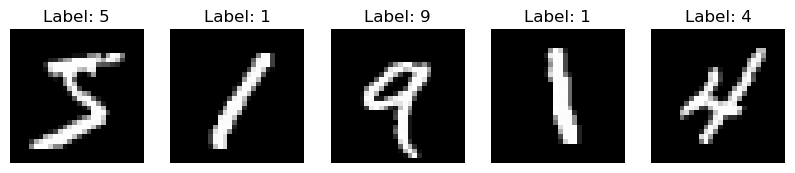

In [3]:
# Create a DataLoader without shuffling
trainloader_no_shuffle = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=False)

# Get a batch of training images
dataiter = iter(trainloader_no_shuffle)
images, labels = next(dataiter)  # Get the first batch of images

# Select specific indices of images you want to use
selected_indices = [0, 3, 4, 6, 9]  # Example indices

# Display the selected images and their labels
plt.figure(figsize=(10, 4))
for i, idx in enumerate(selected_indices):
    plt.subplot(1, len(selected_indices), i+1)
    plt.imshow(images[idx].numpy().squeeze(), cmap='gray')
    plt.title(f'Label: {labels[idx].item()}')
    plt.axis('off')
plt.show()


### Defining the Neural Network

We create a simple fully connected neural network:

- Input: 28×28 image flattened to 784
- Hidden layer: 128 neurons with ReLU
- Output: 10 classes (digits 0–9)

In [4]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleNN()

### Loss Function and Optimizer

- Loss: CrossEntropyLoss (for classification)
- Optimizer: Adam with learning rate 0.001

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Training the Model

Steps:
- Forward pass
- Compute loss
- Backpropagation
- Update weights

In [6]:
for epoch in range(1):
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    print(f'Epoch {epoch + 1} completed')

print('Finished Training')

Epoch 1 completed
Finished Training


### Testing the Model

- Load test data
- Select specific images
- Generate predictions

In [7]:
testloader_no_shuffle = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False
)

dataiter = iter(testloader_no_shuffle)
images, labels = next(dataiter)

selected_indices = [0, 3, 4, 6, 9]

outputs = model(images[selected_indices])
_, predicted = torch.max(outputs, 1)

### Visualizing Predictions

Display test images along with predicted labels.

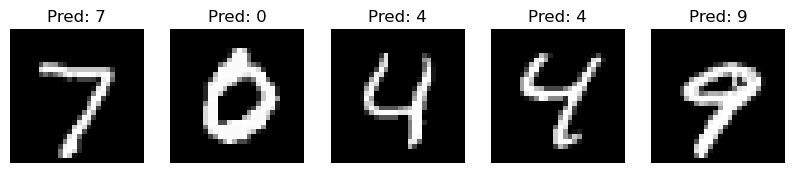

In [8]:
plt.figure(figsize=(10, 4))
for i, idx in enumerate(selected_indices):
    plt.subplot(1, len(selected_indices), i+1)
    plt.imshow(images[idx].numpy().squeeze(), cmap='gray')
    plt.title(f'Pred: {predicted[i].item()}')
    plt.axis('off')

plt.show()